In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import time
import gc
import pickle
from datetime import datetime
import cmaps
# 配置参数
from pathlib import Path

FIG_SAVE_DIR = "./figures/omega_region_mean/"

# 创建必要的目录
for d in [ FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)

# 实验列表
EXPERIMENTS = ['CNTL', 'P4K', '4CO2']


In [2]:
wa_cntl = xr.open_dataarray("omega_cntl_layers/wa_all_levels.nc")
wa_p4k = xr.open_dataarray("omega_p4k_layers/wa_all_levels.nc")
wa_4co2 = xr.open_dataarray("omega_4co2_layers/wa_all_levels.nc")
wa_cntl

<xarray.DataArray 'wa' (level: 22, time: 5114, lat: 15, lon: 180)> Size: 2GB
[303771600 values with dtype=float64]
Coordinates:
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

In [3]:

# 计算各实验的时间-经纬度平均
wa_cntl_mean = wa_cntl.mean(dim=['time', 'lat', 'lon'])
wa_p4k_mean = wa_p4k.mean(dim=['time', 'lat', 'lon'])
wa_4co2_mean = wa_4co2.mean(dim=['time', 'lat', 'lon'])


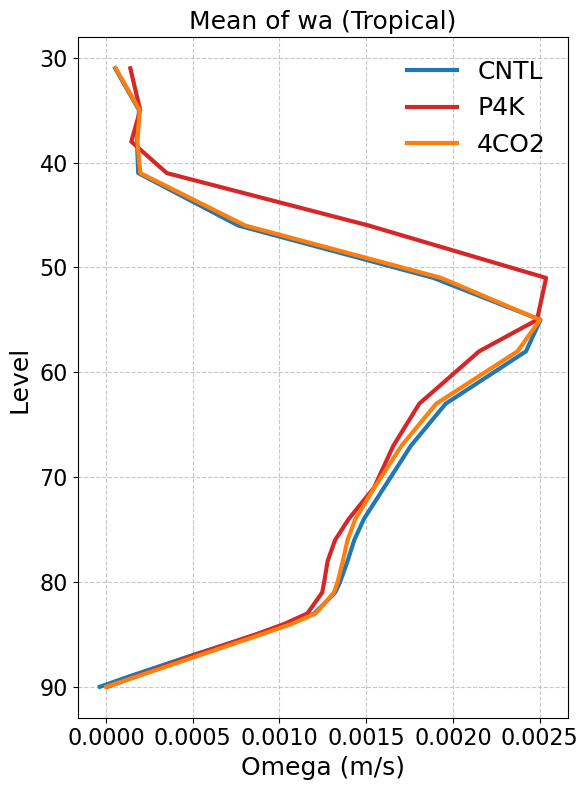

In [4]:


# 配色方案：CNTL 蓝色，P4K 橙色，4CO2 红色
colors = {'CNTL':'#1f77b4', 'P4K':'#d62728', '4CO2':'#ff7f0e'}
linewidth = 3

plt.figure(figsize=(6, 8))
plt.plot(wa_cntl_mean, wa_cntl['level'], label='CNTL', color=colors['CNTL'], linewidth=linewidth)
plt.plot(wa_p4k_mean, wa_p4k['level'], label='P4K', color=colors['P4K'], linewidth=linewidth)
plt.plot(wa_4co2_mean, wa_4co2['level'], label='4CO2', color=colors['4CO2'], linewidth=linewidth)

plt.gca().invert_yaxis()  # 气压从上到下
plt.xlabel('Omega (m/s)', fontsize=18)
plt.ylabel('Level ', fontsize=18)
plt.title('Mean of wa (Tropical)', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=16)

plt.legend(frameon=False, fontsize=18)
plt.grid(True, linestyle='--', alpha=0.7)  # 虚线网格，更学术
plt.tight_layout()
plt.show()


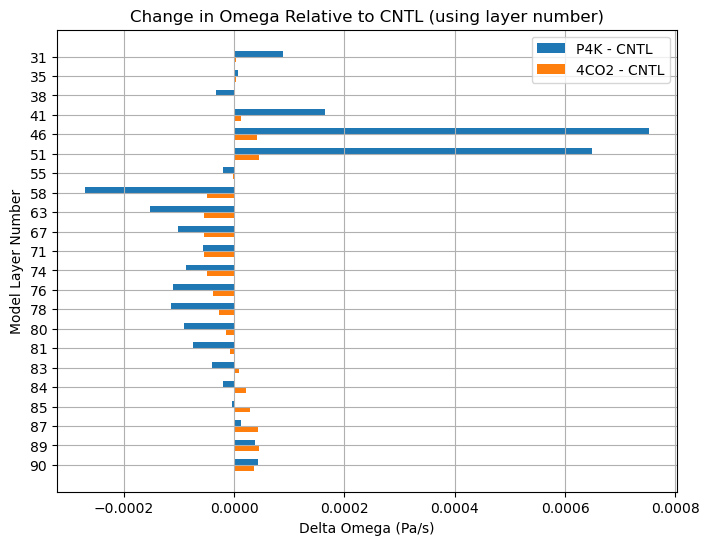

注意：上图使用模式层数。下面的分析将使用 zg 高度数据（仅海洋）进行更精确的分析。


In [5]:
# 2. 计算相对于 CNTL 的变化（每层）
wa_p4k_delta  = wa_p4k_mean - wa_cntl_mean
wa_4co2_delta = wa_4co2_mean - wa_cntl_mean

levels = wa_cntl['level'].values  # 假设22层

# 3. 绘制柱状图（使用层数作为 y 轴 - 旧方法）
width = 0.3  # 柱宽
y = np.arange(len(levels))

plt.figure(figsize=(8,6))
plt.barh(y - width/2, wa_p4k_delta.values, height=width, label='P4K - CNTL')
plt.barh(y + width/2, wa_4co2_delta.values, height=width, label='4CO2 - CNTL')

plt.yticks(y, levels)
plt.gca().invert_yaxis()  # 气压从上到下
plt.xlabel('Delta Omega (Pa/s)')
plt.ylabel('Model Layer Number')
plt.title('Change in Omega Relative to CNTL (using layer number)')
plt.legend()
plt.grid(True)
plt.show()

print("注意：上图使用模式层数。下面的分析将使用 zg 高度数据（仅海洋）进行更精确的分析。")

In [6]:


# 2. 找到每个实验最大值所在的层
idx_max_cntl = wa_cntl_mean.argmax(dim='level').values
idx_max_p4k  = wa_p4k_mean.argmax(dim='level').values
idx_max_4co2 = wa_4co2_mean.argmax(dim='level').values

max_layer_cntl = wa_cntl['level'][idx_max_cntl].values
max_layer_p4k  = wa_p4k['level'][idx_max_p4k].values
max_layer_4co2 = wa_4co2['level'][idx_max_4co2].values

# 3. 对应最大值
max_wa_cntl = wa_cntl_mean.values[idx_max_cntl]
max_wa_p4k  = wa_p4k_mean.values[idx_max_p4k]
max_wa_4co2 = wa_4co2_mean.values[idx_max_4co2]

# 4. 计算与 CNTL 最大值的差异（数值差异）
delta_p4k  = max_wa_p4k - max_wa_cntl
delta_4co2 = max_wa_4co2 - max_wa_cntl


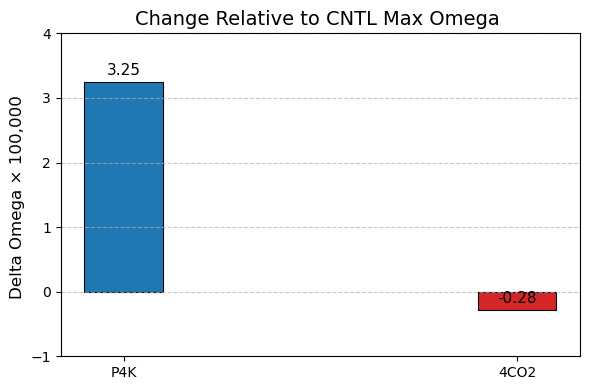

In [7]:

scale = 1e5

# 学术配色方案：使用蓝色/红色渐变色
colors = ['#1f77b4', '#d62728']  # 蓝色、红色（matplotlib 默认学术配色）

plt.figure(figsize=(6,4))
bars = plt.bar(['P4K', '4CO2'], [delta_p4k*scale, delta_4co2*scale], color=colors, edgecolor='black', linewidth=0.8,
               width=0.2)
plt.ylabel(f'Delta Omega × {int(scale):,} ', fontsize=12)
plt.title('Change Relative to CNTL Max Omega ', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(-1, 4)

# 在柱上标注数值
for bar, val in zip(bars, [delta_p4k, delta_4co2]):
    height = val*scale
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.06, f'{height:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


In [8]:
data_path = Path('/work/mh1498/m301257/')

# 读取海洋 mask
print("读取陆地mask...")
land_mask = xr.open_dataset(data_path / 'processed_data/land_mask_2deg.nc')
ocean_mask = land_mask['__xarray_dataarray_variable__'] == 0  # 海洋为True
print(f"✓ Ocean grid points: {ocean_mask.sum().values}/{ocean_mask.size}")

# 对 wa 数据应用海洋 mask
wa_cntl_ocean = wa_cntl.where(ocean_mask)
wa_p4k_ocean  = wa_p4k.where(ocean_mask)
wa_4co2_ocean = wa_4co2.where(ocean_mask)

# 时间-经纬度平均（只统计海洋格点，skipna=True）
wa_cntl_mean_ocean = wa_cntl_ocean.mean(dim=['time', 'lat', 'lon'], skipna=True)
wa_p4k_mean_ocean  = wa_p4k_ocean.mean(dim=['time', 'lat', 'lon'], skipna=True)
wa_4co2_mean_ocean = wa_4co2_ocean.mean(dim=['time', 'lat', 'lon'], skipna=True)

# 找每个实验最大值及对应层
idx_max_cntl = wa_cntl_mean_ocean.argmax(dim='level').values
idx_max_p4k  = wa_p4k_mean_ocean.argmax(dim='level').values
idx_max_4co2 = wa_4co2_mean_ocean.argmax(dim='level').values

max_layer_cntl_ocean = wa_cntl_ocean['level'][idx_max_cntl].values
max_layer_p4k_ocean  = wa_p4k_ocean['level'][idx_max_p4k].values
max_layer_4co2_ocean = wa_4co2_ocean['level'][idx_max_4co2].values

max_wa_cntl_ocean = wa_cntl_mean_ocean.values[idx_max_cntl]
max_wa_p4k_ocean  = wa_p4k_mean_ocean.values[idx_max_p4k]
max_wa_4co2_ocean = wa_4co2_mean_ocean.values[idx_max_4co2]

# 数值差异
delta_p4k_ocean  = max_wa_p4k_ocean - max_wa_cntl_ocean
delta_4co2_ocean = max_wa_4co2_ocean - max_wa_cntl_ocean


读取陆地mask...
✓ Ocean grid points: 2089/2700


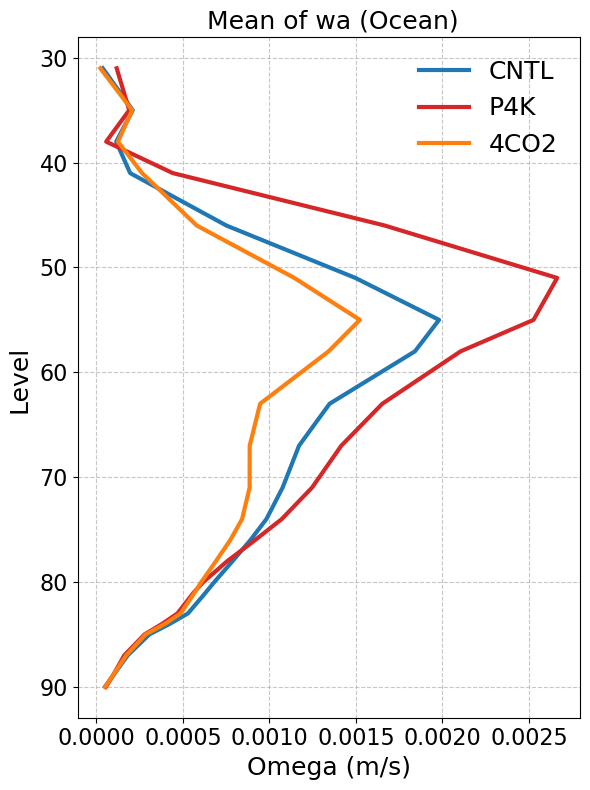

In [9]:

# 配色方案：CNTL 蓝色，P4K 橙色，4CO2 红色
colors = {'CNTL':'#1f77b4', 'P4K':'#d62728', '4CO2':'#ff7f0e'}
linewidth = 3

plt.figure(figsize=(6, 8))
plt.plot(wa_cntl_mean_ocean, wa_cntl['level'], label='CNTL', color=colors['CNTL'], linewidth=linewidth)
plt.plot(wa_p4k_mean_ocean, wa_p4k['level'], label='P4K', color=colors['P4K'], linewidth=linewidth)
plt.plot(wa_4co2_mean_ocean, wa_4co2['level'], label='4CO2', color=colors['4CO2'], linewidth=linewidth)

plt.gca().invert_yaxis()  # 气压从上到下
plt.xlabel('Omega (m/s)', fontsize=18)
plt.ylabel('Level ', fontsize=18)
plt.title(' Mean of wa (Ocean)', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(frameon=False, fontsize=18)
plt.grid(True, linestyle='--', alpha=0.7)  # 虚线网格，更学术
plt.tight_layout()
plt.show()


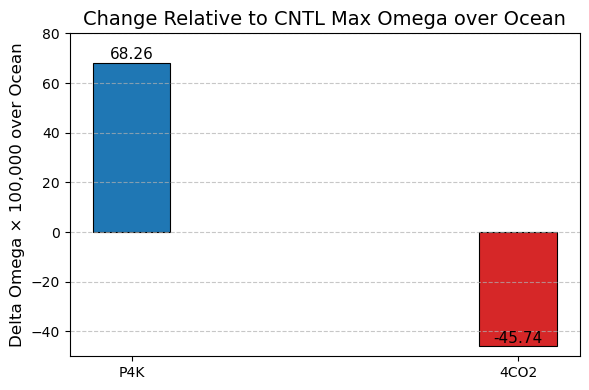

In [10]:

scale = 1e5

# 学术配色方案：使用蓝色/红色渐变色
colors = ['#1f77b4', '#d62728']  # 蓝色、红色（matplotlib 默认学术配色）

plt.figure(figsize=(6,4))
bars = plt.bar(['P4K', '4CO2'], [delta_p4k_ocean*scale, delta_4co2_ocean*scale], color=colors, edgecolor='black', linewidth=0.8,
               width=0.2)
plt.ylabel(f'Delta Omega × {int(scale):,} over Ocean', fontsize=12)
plt.title('Change Relative to CNTL Max Omega over Ocean', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(-50, 80)

for bar, val in zip(bars, [delta_p4k_ocean*scale, delta_4co2_ocean*scale]):
    height = val
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.06, f'{height:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


# 使用 zg 高度数据分析（仅海洋）

下面我们使用处理好的 zg（位势高度）数据来替代模式层数作为 y 轴。
由于 zg 数据在海洋上是相同高度（不随地形变化），我们将：
1. 加载各实验的 zg 数据（仅海洋部分）
2. 计算每个实验中 wa 最大值对应的高度
3. 比较不同实验间的高度变化

In [11]:
# 1. 加载 zg 数据（位势高度，单位：m）
print("读取 zg 数据...")
zg_cntl = xr.open_dataset('processed_data/zg_2deg_interp_cntl.nc')['zg']
zg_p4k = xr.open_dataset('processed_data/zg_2deg_interp_p4k.nc')['zg']
zg_4co2 = xr.open_dataset('processed_data/zg_2deg_interp_4co2.nc')['zg']

# 2. 应用海洋 mask（与之前相同的 ocean_mask）
zg_cntl_ocean = zg_cntl.where(ocean_mask)
zg_p4k_ocean = zg_p4k.where(ocean_mask)
zg_4co2_ocean = zg_4co2.where(ocean_mask)

# 3. 计算海洋平均高度（对每一层）
# zg 不随时间变化，所以只对空间平均
zg_cntl_mean = zg_cntl_ocean.mean(dim=['lat', 'lon'], skipna=True)
zg_p4k_mean = zg_p4k_ocean.mean(dim=['lat', 'lon'], skipna=True)
zg_4co2_mean = zg_4co2_ocean.mean(dim=['lat', 'lon'], skipna=True)

# 转换为 km 单位
zg_cntl_km = zg_cntl_mean / 1000.0
zg_p4k_km = zg_p4k_mean / 1000.0
zg_4co2_km = zg_4co2_mean / 1000.0

print(f"✓ zg 数据加载完成")
print(f"  高度范围: {zg_cntl_km.min().values:.2f} - {zg_cntl_km.max().values:.2f} km")
print(f"  层数: {len(zg_cntl_km)}")

读取 zg 数据...
✓ zg 数据加载完成
  高度范围: 0.01 - 22.86 km
  层数: 22


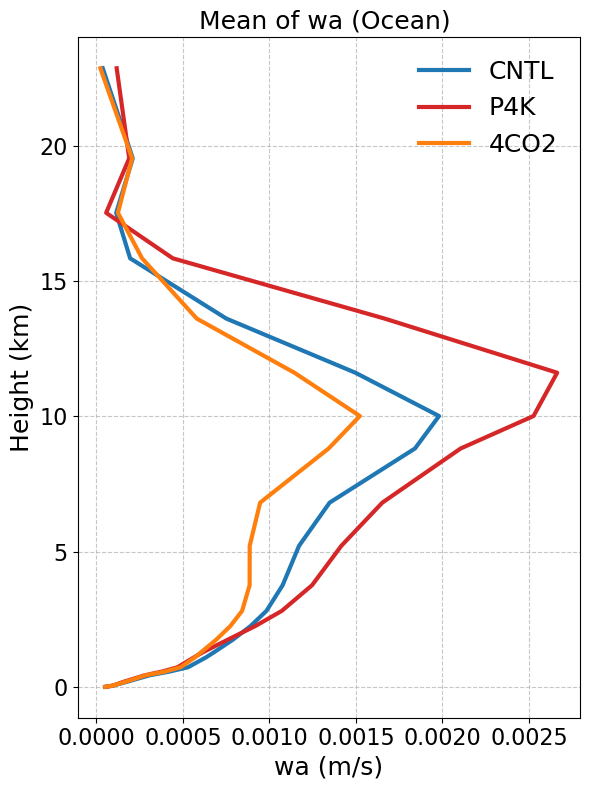

✓ 图像已保存至: ./figures/omega_region_mean//wa_profile_vs_height_ocean.png


In [28]:
# 4. 绘制 wa 廓线，使用 zg 高度（km）作为 y 轴
colors = {'CNTL':'#1f77b4', 'P4K':'#d62728', '4CO2':'#ff7f0e'}
linewidth = 3

plt.figure(figsize=(6, 8))
plt.plot(wa_cntl_mean_ocean, zg_cntl_km, label='CNTL', color=colors['CNTL'], linewidth=linewidth)
plt.plot(wa_p4k_mean_ocean, zg_p4k_km, label='P4K', color=colors['P4K'], linewidth=linewidth)
plt.plot(wa_4co2_mean_ocean, zg_4co2_km, label='4CO2', color=colors['4CO2'], linewidth=linewidth)

# y 轴：上方为高空，下方为地表
plt.xlabel('wa (m/s)', fontsize=18)
plt.ylabel('Height (km)', fontsize=18)
plt.title('Mean of wa (Ocean) ', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(frameon=False, fontsize=18)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'{FIG_SAVE_DIR}/wa_profile_vs_height_ocean.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ 图像已保存至: {FIG_SAVE_DIR}/wa_profile_vs_height_ocean.png")

In [13]:
# 5. 计算每个实验中 wa 最大值所在的高度
# 复用之前计算的 idx_max_* 索引

# 找到最大值对应的高度（单位：km）
height_max_cntl = zg_cntl_km.values[idx_max_cntl]
height_max_p4k = zg_p4k_km.values[idx_max_p4k]
height_max_4co2 = zg_4co2_km.values[idx_max_4co2]

print("="*60)
print("各实验 wa 最大值所在高度：")
print(f"  CNTL:  {height_max_cntl:.3f} km  (layer {max_layer_cntl_ocean})")
print(f"  P4K:   {height_max_p4k:.3f} km  (layer {max_layer_p4k_ocean})")
print(f"  4CO2:  {height_max_4co2:.3f} km  (layer {max_layer_4co2_ocean})")
print("="*60)

# 6. 计算相对于 CNTL 的高度变化（单位：m）
delta_height_p4k = (height_max_p4k - height_max_cntl) * 1000  # 转换为 m
delta_height_4co2 = (height_max_4co2 - height_max_cntl) * 1000  # 转换为 m

print("\n相对于 CNTL 的高度变化：")
print(f"  P4K - CNTL:   {delta_height_p4k:+.1f} m")
print(f"  4CO2 - CNTL:  {delta_height_4co2:+.1f} m")
print("="*60)

各实验 wa 最大值所在高度：
  CNTL:  10.016 km  (layer 55)
  P4K:   11.616 km  (layer 51)
  4CO2:  10.016 km  (layer 55)

相对于 CNTL 的高度变化：
  P4K - CNTL:   +1600.0 m
  4CO2 - CNTL:  +0.0 m


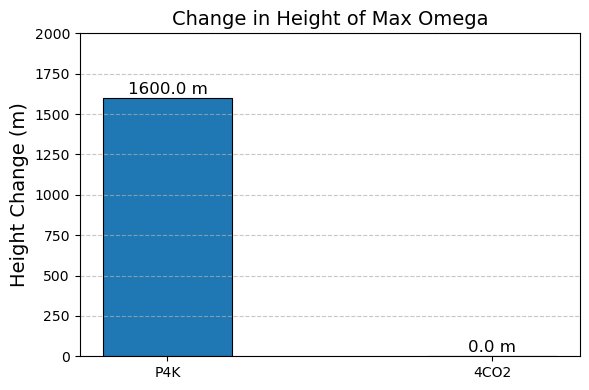

✓ 图像已保存至: ./figures/omega_region_mean//height_change_max_omega_ocean.png


In [26]:
# 7. 绘制高度变化的柱状图
colors = ['#1f77b4', '#d62728']  # 蓝色、红色

plt.figure(figsize=(6, 4))
bars = plt.bar(['P4K', '4CO2'], 
               [delta_height_p4k, delta_height_4co2], 
               color=colors, 
               edgecolor='black', 
               linewidth=0.8,
               width=0.4)

plt.ylabel('Height Change (m)', fontsize=14)
plt.title('Change in Height of Max Omega', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)  # 添加零线
plt.ylim(0,2000)
# 在柱上标注数值
for bar, val in zip(bars, [delta_height_p4k, delta_height_4co2]):
    height = val
    va =  'top'
    offset = 100 
    plt.text(bar.get_x() + bar.get_width()/2, 
             height + offset, 
             f'{height:.1f} m', 
             ha='center', 
             va=va, 
             fontsize=12,
             )

plt.tight_layout()
plt.savefig(f'{FIG_SAVE_DIR}/height_change_max_omega_ocean.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ 图像已保存至: {FIG_SAVE_DIR}/height_change_max_omega_ocean.png")

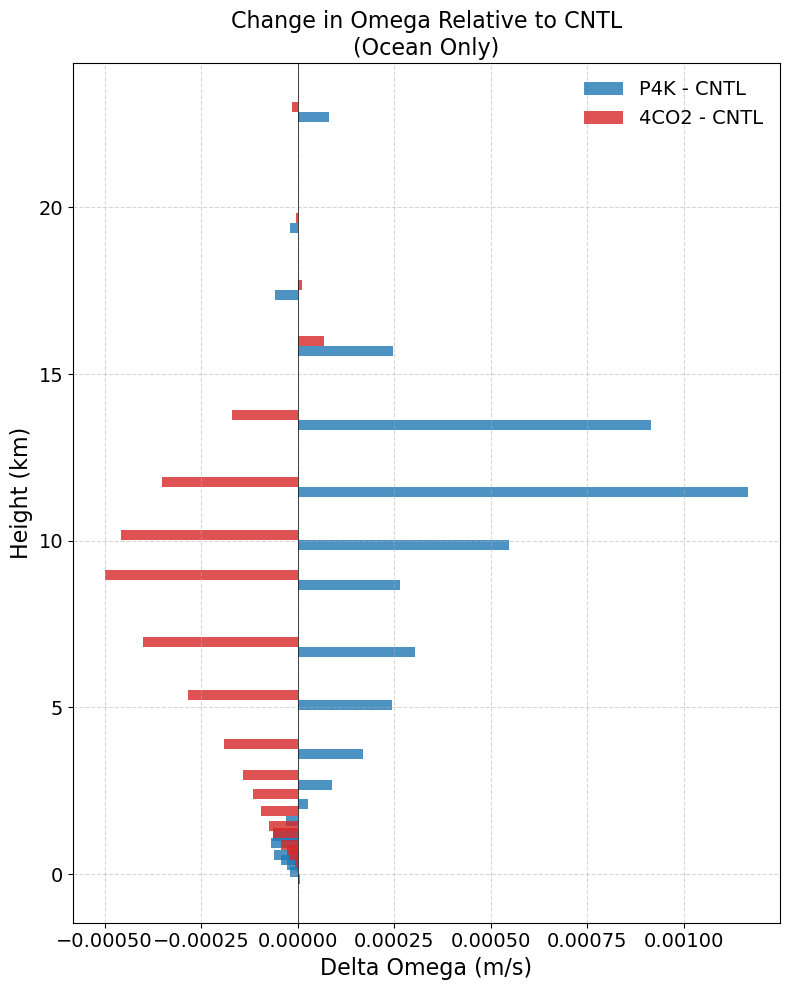

✓ 图像已保存至: ./figures/omega_region_mean//omega_change_vs_height_ocean.png


In [24]:
# 8. 绘制每层的高度变化对比图（相对于 CNTL 的差值廓线）
# 计算每层的高度（使用 zg）
wa_p4k_delta_ocean = wa_p4k_mean_ocean - wa_cntl_mean_ocean
wa_4co2_delta_ocean = wa_4co2_mean_ocean - wa_cntl_mean_ocean

# 绘制柱状图，使用高度作为 y 轴
width_km = 0.3  # 柱宽（单位：km）

plt.figure(figsize=(8, 10))

# 使用 zg 高度而不是层数
y_positions = zg_cntl_km.values

plt.barh(y_positions - width_km/2, wa_p4k_delta_ocean.values, 
         height=width_km, label='P4K - CNTL', color='#1f77b4', alpha=0.8)
plt.barh(y_positions + width_km/2, wa_4co2_delta_ocean.values, 
         height=width_km, label='4CO2 - CNTL', color='#d62728', alpha=0.8)

# y 轴：上方为高空，下方为地表
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)  # 零线
plt.xlabel('Delta Omega (m/s)', fontsize=16)
plt.ylabel('Height (km)', fontsize=16)
plt.title('Change in Omega Relative to CNTL\n(Ocean Only)', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(frameon=False, fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{FIG_SAVE_DIR}/omega_change_vs_height_ocean.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ 图像已保存至: {FIG_SAVE_DIR}/omega_change_vs_height_ocean.png")

In [25]:
# 9. 详细对比表格：展示各实验的关键信息
import pandas as pd

# 创建对比表格
comparison_data = {
    'Experiment': ['CNTL', 'P4K', '4CO2'],
    'Max Omega (m/s)': [
        f'{max_wa_cntl_ocean:.6f}',
        f'{max_wa_p4k_ocean:.6f}',
        f'{max_wa_4co2_ocean:.6f}'
    ],
    'Height of Max (km)': [
        f'{height_max_cntl:.3f}',
        f'{height_max_p4k:.3f}',
        f'{height_max_4co2:.3f}'
    ],
    'Model Layer': [
        f'{int(max_layer_cntl_ocean)}',
        f'{int(max_layer_p4k_ocean)}',
        f'{int(max_layer_4co2_ocean)}'
    ],
    'Δ Omega (×10⁵)': [
        '0.00',
        f'{delta_p4k_ocean*1e5:+.2f}',
        f'{delta_4co2_ocean*1e5:+.2f}'
    ],
    'Δ Height (m)': [
        '0.0',
        f'{delta_height_p4k:+.1f}',
        f'{delta_height_4co2:+.1f}'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("各实验对比表格（仅海洋）")
print("="*80)
print(df_comparison.to_string(index=False))
print("="*80)
print("\n关键发现：")
print(f"  • P4K 相比 CNTL: omega 增强 {delta_p4k_ocean*1e5:.2f}×10⁻⁵ m/s，高度变化 {delta_height_p4k:+.1f} m")
print(f"  • 4CO2 相比 CNTL: omega 增强 {delta_4co2_ocean*1e5:.2f}×10⁻⁵ m/s，高度变化 {delta_height_4co2:+.1f} m")
print("="*80)


各实验对比表格（仅海洋）
Experiment Max Omega (m/s) Height of Max (km) Model Layer Δ Omega (×10⁵) Δ Height (m)
      CNTL        0.001980             10.016          55           0.00          0.0
       P4K        0.002663             11.616          51         +68.26      +1600.0
      4CO2        0.001523             10.016          55         -45.74         +0.0

关键发现：
  • P4K 相比 CNTL: omega 增强 68.26×10⁻⁵ m/s，高度变化 +1600.0 m
  • 4CO2 相比 CNTL: omega 增强 -45.74×10⁻⁵ m/s，高度变化 +0.0 m
